In [1]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
df=pd.read_csv("Multilablel Cyberbully Data.csv")
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam
10213,female,social,দুধের পাহাড়,1,1,0,0,0
1958,male,politics,পুরকা পরে আবার পালাতে হবে সময় এসে গেছে,1,0,0,0,0
4872,male,social,এক সহোস সাইটার মোড কি বাভে পানিতা,1,0,0,0,0
12345,male,social,জুতা মার জাহিদে মুখে,1,0,0,1,0
5939,male,sports,ছোটবেলায় এর উপর উঠে একবার পড়ে গেছিলাম আর জীবনে...,0,0,0,0,0
5353,female,social,মেয়েরা পর্দা তে অনেক সুন্দর এবং মায়াবী,0,0,0,0,0
12454,female,actor,জুতা মার নাস্তিকের গালে কোন সালায় ইতির নাটক দেখে,1,0,1,1,0
10880,male,social,একটা একটা নাস্তিক ধর কাইট্রা কাইট্রা বস্তায় ভর,1,0,1,1,0
10273,female,social,এই পুরো ভিডিও টা কোথায় পাবো,0,0,0,0,0
5084,male,social,ভাইয়া গানটা কোন জায়গায় গাইছেন কালকাটের ভিতরে,1,0,0,0,0


In [3]:
#check the rows and columns number.
print(f"number of rows:--> {df.shape[0]} and number of columns:--> {df.shape[1]}")

number of rows:--> 12546 and number of columns:--> 8


In [4]:
#check for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12546 entries, 0 to 12545
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      12546 non-null  object
 1   Profession  12546 non-null  object
 2   comment     12546 non-null  object
 3   bully       12546 non-null  int64 
 4   sexual      12546 non-null  int64 
 5   religious   12546 non-null  int64 
 6   threat      12546 non-null  int64 
 7   spam        12546 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 784.3+ KB


In [5]:
#check for missing values
def checking_m(df):
    null_v = df.isnull().sum().sort_values(ascending=False)
    null_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    null_v = pd.concat([null_v, null_percent], axis=1, keys=['Missing_Number', 'Missing_Percent'])
    return null_v

checking_m(df)

,Missing_Number,Missing_Percent
Gender,0,0.0
Profession,0,0.0
comment,0,0.0
bully,0,0.0
sexual,0,0.0
religious,0,0.0
threat,0,0.0
spam,0,0.0


In [6]:
#check for dublicated rows
print("Numbers of duplicated rows :",df.duplicated().sum())

Numbers of duplicated rows : 1291


In [7]:
#counting text length
df['count'] = df['comment'].str.split().str.len()

# Remove the text with words less than 3
df= df.loc[df['count']>2]


In [8]:
df.shape

(10188, 9)

In [9]:
df.sample(50)

,Gender,Profession,comment,bully,sexual,religious,threat,spam,count
11861,female,singer,এই সব ঘটনার বিচার চাই,1,0,0,1,0,5
4648,male,dancer,কি শুনছি এসব,1,0,0,0,0,3
3218,female,politics,নির্বাচন হলে আওয়ামী লীগে ভোট পাবেনা গ্যারান্টি,0,0,0,0,0,7
9625,female,actor,যে কেউ ফলো ভারতে চান ফলো করুন এবং লিঙ্ক কপি কর...,0,0,0,0,1,16
5058,male,social,আর জায়গায় পান নাই,1,0,0,0,0,4
10479,female,actor,রিপ্লে ভিডিও না দিলে তুমি আমার বউ,1,0,0,0,0,7
5410,female,social,সবাই একটু সাপোর্ট করো প্লিজ প্লিজ প্লিজ আমি নত...,0,0,0,0,1,10
7581,female,social,এই বিড়ালটা যদি আমি হতাম তাইলে খাইয়া ছাইড়া দিতাম,1,0,0,0,0,9
8931,female,social,বিরাল এর জাইগাই জদি আমি হইতাম,1,1,0,0,0,6
4917,male,social,আর কোন যায়গা পান নাই,1,0,0,0,0,5


In [10]:
import re

def clean_bangla_text(text):
    # Remove English letters and digits only
    text = re.sub(r'[A-Za-z0-9]', '', text)

    # Remove unwanted punctuation (but keep । ! ? , )
    text = re.sub(r'[“”"\'’‘`^~–—…•°•→←<>/\\|_=+()*&^%$#@{}[\]<>]', ' ', text)

    # Remove newlines and tabs
    text = text.replace("\n", " ").replace("\t", " ")

    # Normalize multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['comment'] = df['comment'].apply(clean_bangla_text)

In [11]:
df.sample(10)

,Gender,Profession,comment,bully,sexual,religious,threat,spam,count
10435,female,social,সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু স...,0,0,0,0,1,10
11505,female,actor,মার জুতা মাগিরে,1,0,0,1,0,3
9064,female,social,বিরালে দুদু খাবে,1,1,0,0,0,3
4804,male,social,পাসের ভাইয়া তা ও এক সুন্দর গাইসে,0,0,0,0,0,7
4218,female,actor,আমার দিয়া একটা রিপ্লাই ভিডিও চাই এবং সাপোর্ট,0,0,0,0,1,9
7215,female,social,ও মাই গড আমি এইটা কি দেখলাম,1,0,0,0,0,7
9027,female,social,অনেক বড় মাপের একটা মাগি,1,0,0,0,0,5
11665,female,actor,আজ থেকে তর সকল নাটক থেকে নিজেকে ফিরিয়ে নিলামদূ...,1,0,1,1,0,13
8116,female,social,কি খারাপ মহিলা,1,0,0,0,0,3
1586,male,sports,আপনার মুখ টা কি দেখা যাবে,0,0,0,0,0,6


In [12]:
# Length of each cleaned comment (in tokens/words, split by space)
df['token_len'] = df['comment'].apply(lambda x: len(x.split()))

# Maximum token length
max_token_len = df['token_len'].max()

print("Maximum token length:", max_token_len)
df[['comment', 'token_len']].head()


Maximum token length: 178


,comment,token_len
0,এই দেশে এইসব কি হচ্ছে,5
1,মানে কি বলব,3
2,ভাই ভিডিও ফুল প্লিজ,4
3,নিজের খরচ নিজেই চালাতে পারবেন এমন ভালো একটা জব...,14
4,ভিডিও কলে রেগুলার কাজ করতে পারবেন,6


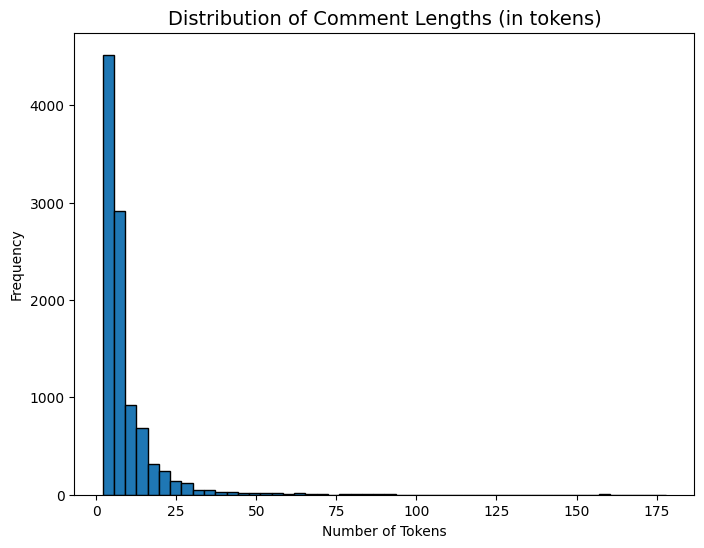

In [13]:
import matplotlib.pyplot as plt

# Distribution of token lengths (assuming you already added df['token_len'])
plt.figure(figsize=(8,6))
plt.hist(df['token_len'], bins=50, edgecolor='black')
plt.title("Distribution of Comment Lengths (in tokens)", fontsize=14)
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.show()


In [14]:
# Define label columns
label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Prepare features and labels
texts = df['comment'].values
labels = df[label_cols].values.astype(np.float32)

labels

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 1.],
       ...,
       [1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       [1., 0., 1., 0., 0.]], dtype=float32)

In [15]:
print(f"Dataset size: {len(texts)}")
print(f"Label distribution:\n{df[label_cols].sum()}")


Dataset size: 10188
Label distribution:
bully        6882
sexual       1802
religious    1445
threat       1403
spam          933
dtype: int64


In [16]:
# Train-validation-test split (80-10-10)
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels.sum(axis=1)
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp.sum(axis=1)
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")


Train: 8150, Val: 1019, Test: 1019


In [17]:
import pandas as pd
from sklearn.utils import resample
import numpy as np

# ======================================================
# BALANCE (RESAMPLE) TRAINING DATA — Match to Max Class Count
# ======================================================

label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

# Ensure DataFrame format
X_train_df = pd.DataFrame(X_train, columns=["comment"])
y_train_df = pd.DataFrame(y_train, columns=label_cols)

# Combine for easier handling
train_df = pd.concat([X_train_df.reset_index(drop=True), y_train_df.reset_index(drop=True)], axis=1)

print("\nOriginal training label distribution:")
print(train_df[label_cols].sum())

# -------------------------------------------------------
# Target = size of the largest class
# -------------------------------------------------------
max_count = int(train_df[label_cols].sum().max())
print(f"\n🎯 Target samples per class (max-upsampled): {max_count}")

# -------------------------------------------------------
# Upsample all minority classes to match the majority
# -------------------------------------------------------
resampled_dfs = [train_df]
generated_counts = {}

for label in label_cols:
    df_label = train_df[train_df[label] == 1]
    n_current = len(df_label)

    if n_current < max_count:
        df_upsampled = resample(
            df_label,
            replace=True,
            n_samples=max_count - n_current,
            random_state=42
        )
        resampled_dfs.append(df_upsampled)
        generated_counts[label] = len(df_upsampled)
    else:
        generated_counts[label] = 0

# Combine and shuffle
train_balanced = pd.concat(resampled_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

# Save balanced training data
train_balanced.to_csv("balanced_train_data.csv", index=False)

# Load from CSV
train_balanced = pd.read_csv("balanced_train_data.csv")

# Split back into X and y
label_cols = ['bully', 'sexual', 'religious', 'threat', 'spam']

print(f"✅ Loaded balanced data: {len(X_train)} samples")


# Split back into arrays for model training
X_train = train_balanced["comment"].reset_index(drop=True).values
y_train = train_balanced[label_cols].reset_index(drop=True).values.astype(np.float32)

# -------------------------------------------------------
# Summary
# -------------------------------------------------------
print("\n✅ Final balanced training distribution:")
print(train_balanced[label_cols].sum())

print("\n📈 Generated (added) samples per class:")
print(generated_counts)

print(f"\nTotal final balanced training size: {len(X_train)}")



Original training label distribution:
bully        5497.0
sexual       1447.0
religious    1160.0
threat       1116.0
spam          752.0
dtype: float32

🎯 Target samples per class (max-upsampled): 5497
✅ Loaded balanced data: 8150 samples

✅ Final balanced training distribution:
bully        16472.0
sexual        6189.0
religious     7418.0
threat        6841.0
spam          5986.0
dtype: float64

📈 Generated (added) samples per class:
{'bully': 0, 'sexual': 4050, 'religious': 4337, 'threat': 4381, 'spam': 4745}

Total final balanced training size: 25663


In [18]:
X_train

array(['ওই টা সে দেখতে', 'তোরে আমি চুদে দেবো খানকির পোলা',
       'আগে টান্ডা করে তারপর টেটো লাগায়', ...,
       'এতো জায়গা রেখে এখানে আপনারা কি করতে গিয়েছেন',
       'নৌকা সারা জীবন ভেছে থাকেনা ব্যন্না আসলে ঠিক ডুবি দিয়ে জাবে ইনশাআল্লাহ আই লাভার বিএনপি আপনি চালিয়ে জান আপু জনোগন আছে আর থাকবেও আলহাদুল্লিহ',
       'অসাধারণ চমংকার বিউটিফুল কপিলিংক করে দিলাম'], dtype=object)

In [19]:
len(X_train), len(y_train)

(25663, 25663)

In [20]:
# ========================
# 2. DATASET CLASS
# ========================

class CyberbullyingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = list(texts)
        if isinstance(labels, pd.DataFrame):
            self.labels = labels.values
        else:
            self.labels = np.array(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]  # now works fine with numpy

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.float)
        }


In [21]:
# ========================
# 4. TRAINING FUNCTION
# ========================

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc='Training')

    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        logits = model(input_ids, attention_mask)
        loss = nn.BCEWithLogitsLoss()(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        # Calculate accuracy
        preds = torch.sigmoid(logits) > 0.5
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

    return avg_loss, accuracy

def eval_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []

    progress_bar = tqdm(dataloader, desc='Validation')

    with torch.no_grad():
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask)
            loss = nn.BCEWithLogitsLoss()(logits, labels)

            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = probs > 0.5

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            progress_bar.set_postfix({'loss': loss.item()})

    avg_loss = total_loss / len(dataloader)
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

    return avg_loss, accuracy, np.array(all_preds), np.array(all_labels), np.array(all_probs)


In [22]:
# ========================
# 3. MODEL ARCHITECTURE: BERT + LSTM
# ========================

class BERTLSTM(nn.Module):
    def __init__(self, bert_model_name, num_labels, hidden_dim=256, lstm_layers=2, dropout=0.3):
        super(BERTLSTM, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.lstm = nn.LSTM(
            self.bert.config.hidden_size,
            hidden_dim,
            num_layers=lstm_layers,
            bidirectional=False,  # Single direction LSTM
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state  # (batch, seq_len, hidden_size)

        lstm_output, (hidden, cell) = self.lstm(sequence_output)
        # Use the last hidden state from the last layer
        last_hidden = hidden[-1, :, :]  # (batch, hidden_dim)

        last_hidden = self.dropout(last_hidden)
        logits = self.classifier(last_hidden)
        return logits


In [23]:
# ========================
# 5. MAIN TRAINING PIPELINE
# ========================

# Configuration
BERT_MODEL = 'csebuetnlp/banglabert_large'
MAX_LEN = 64
BATCH_SIZE = 32


# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

# Create datasets
train_dataset = CyberbullyingDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = CyberbullyingDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = CyberbullyingDataset(X_test, y_test, tokenizer, MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Initialize BERT+LSTM model
model = BERTLSTM(BERT_MODEL, num_labels=len(label_cols)).to(device)

print(f"\nModel: BERTLSTM")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/880 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.35G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.35G [00:00<?, ?B/s]


Model: BERTLSTM
Total parameters: 337,446,149


In [25]:
!pip install torch-optimizer


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.9 MB/s eta 0:00:00


In [26]:
from transformers import get_linear_schedule_with_warmup
import torch
import torch_optimizer as optim  # <-- RAdam is here

LEARNING_RATE = 1e-5
EPOCHS = 10

# --- RAdam optimizer ---
optimizer = optim.RAdam(
    model.parameters(),
    lr=LEARNING_RATE
)

# --- Scheduler ---
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print("✅ Using RAdam optimizer (from torch-optimizer, lr=1e-5)")


✅ Using RAdam optimizer (from torch-optimizer, lr=1e-5)


In [27]:
# ========================
# 6. TRAINING LOOP
# ========================

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("\n" + "="*50)
print("STARTING TRAINING - BERTLSTM")
print("="*50)

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 50)

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)

    # Validate
    val_loss, val_acc, _, _, _ = eval_epoch(model, val_loader, device)

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save last model checkpoint (not best)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    }, 'last_model_checkpoint_bert_lstm.pt')
    print(f"✓ Last BERTLSTM model checkpoint saved! (Epoch {epoch+1})")

print("\n" + "="*50)
print("TRAINING COMPLETED - BERTLSTM")
print("="*50)

# Print final training and validation metrics
print(f"\nFINAL TRAINING METRICS - BERTLSTM:")
print(f"Last Train Loss: {history['train_loss'][-1]:.4f}")
print(f"Last Train Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Last Validation Loss: {history['val_loss'][-1]:.4f}")
print(f"Last Validation Accuracy: {history['val_acc'][-1]:.4f}")



STARTING TRAINING - BERTLSTM

Epoch 1/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.5879 | Train Acc: 0.7140
Val Loss: 0.3389 | Val Acc: 0.9003
✓ Last BERTLSTM model checkpoint saved! (Epoch 1)

Epoch 2/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0362 | Train Acc: 0.9948
Val Loss: 0.2268 | Val Acc: 0.9342
✓ Last BERTLSTM model checkpoint saved! (Epoch 9)

Epoch 10/10
--------------------------------------------------


Training:   0%|          | 0/802 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 0.0341 | Train Acc: 0.9950
Val Loss: 0.2253 | Val Acc: 0.9348
✓ Last BERTLSTM model checkpoint saved! (Epoch 10)

TRAINING COMPLETED - BERTLSTM

FINAL TRAINING METRICS - BERTLSTM:
Last Train Loss: 0.0341
Last Train Accuracy: 0.9950
Last Validation Loss: 0.2253
Last Validation Accuracy: 0.9348


In [28]:
# ========================
# 7. TEST EVALUATION
# ========================

print("\n" + "="*50)
print("TESTING WITH LAST BERTLSTM MODEL")
print("="*50)

# Load last model checkpoint
# checkpoint = torch.load('last_model_checkpoint_bert_lstm.pt')
# model.load_state_dict(checkpoint['model_state_dict'])

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs = eval_epoch(model, test_loader, device)

print(f"\n{'='*50}")
print(f"TEST RESULTS - BERTLSTM")
print(f"{'='*50}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Hamming Loss: {hamming_loss(test_labels, test_preds):.4f}")



TESTING WITH LAST BERTLSTM MODEL


Validation:   0%|          | 0/32 [00:00<?, ?it/s]


TEST RESULTS - BERTLSTM
Test Loss: 0.2124
Test Accuracy: 0.9397
Hamming Loss: 0.0603


In [29]:
# Calculate precision, recall, F1 scores
precision = precision_score(test_labels, test_preds, average='micro', zero_division=0)
recall = recall_score(test_labels, test_preds, average='micro', zero_division=0)
f1 = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\nOverall Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Overall Metrics:
Precision: 0.8670
Recall: 0.8900
F1-Score: 0.8783


In [30]:


from sklearn.metrics import matthews_corrcoef, cohen_kappa_score
import numpy as np


# Convert to numpy arrays
test_labels_np = np.array(test_labels)
test_preds_np = np.array(test_preds)

class_names = ['bully', 'sexual', 'religious', 'threat', 'spam']



print(f"\n{'='*50}")
print(f"MCC AND COHEN'S KAPPA SCORES")
print(f"{'='*50}")

# Calculate for each class
mcc_scores = []
kappa_scores = []

print("\nPer-class Scores:")
for i, class_name in enumerate(class_names):
    mcc = matthews_corrcoef(test_labels_np[:, i], test_preds_np[:, i])
    kappa = cohen_kappa_score(test_labels_np[:, i], test_preds_np[:, i])

    mcc_scores.append(mcc)
    kappa_scores.append(kappa)

    print(f"{class_name:>10}: MCC = {mcc:.4f}, Cohen's Kappa = {kappa:.4f}")

# Calculate averages
average_mcc = np.mean(mcc_scores)
average_kappa = np.mean(kappa_scores)

print(f"\nAverage Scores:")
print(f"MCC: {average_mcc:.4f}")
print(f"Cohen's Kappa: {average_kappa:.4f}")


MCC AND COHEN'S KAPPA SCORES

Per-class Scores:
     bully: MCC = 0.7370, Cohen's Kappa = 0.7361
    sexual: MCC = 0.6399, Cohen's Kappa = 0.6395
 religious: MCC = 0.9332, Cohen's Kappa = 0.9326
    threat: MCC = 0.8084, Cohen's Kappa = 0.8082
      spam: MCC = 0.8416, Cohen's Kappa = 0.8416

Average Scores:
MCC: 0.7920
Cohen's Kappa: 0.7916


In [31]:
# Per-label metrics
print(f"\n{'='*50}")
print("PER-LABEL CLASSIFICATION REPORT - BERTLSTM")
print(f"{'='*50}")
print(classification_report(
    test_labels,
    test_preds,
    target_names=label_cols,
    zero_division=0
))


PER-LABEL CLASSIFICATION REPORT - BERTLSTM
              precision    recall  f1-score   support

       bully       0.90      0.93      0.92       693
      sexual       0.68      0.72      0.70       155
   religious       0.91      0.97      0.94       143
      threat       0.85      0.82      0.84       164
        spam       0.86      0.86      0.86        90

   micro avg       0.87      0.89      0.88      1245
   macro avg       0.84      0.86      0.85      1245
weighted avg       0.87      0.89      0.88      1245
 samples avg       0.73      0.73      0.72      1245



In [32]:
# Calculate AUC-ROC for each class
print(f"\n{'='*50}")
print("AUC-ROC SCORES FOR EACH CLASS - BERTLSTM")
print(f"{'='*50}")
for i, label in enumerate(label_cols):
    try:
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        print(f"{label}: {auc:.4f}")
    except ValueError:
        print(f"{label}: Could not calculate AUC (only one class present)")

# Calculate overall micro and macro AUC
try:
    micro_auc = roc_auc_score(test_labels, test_probs, average='micro')
    macro_auc = roc_auc_score(test_labels, test_probs, average='macro')
    print(f"\nMicro AUC: {micro_auc:.4f}")
    print(f"Macro AUC: {macro_auc:.4f}")
except ValueError:
    print("\nCould not calculate overall AUC scores")



AUC-ROC SCORES FOR EACH CLASS - BERTLSTM
bully: 0.9289
sexual: 0.9017
religious: 0.9824
threat: 0.9648
spam: 0.9630

Micro AUC: 0.9673
Macro AUC: 0.9482


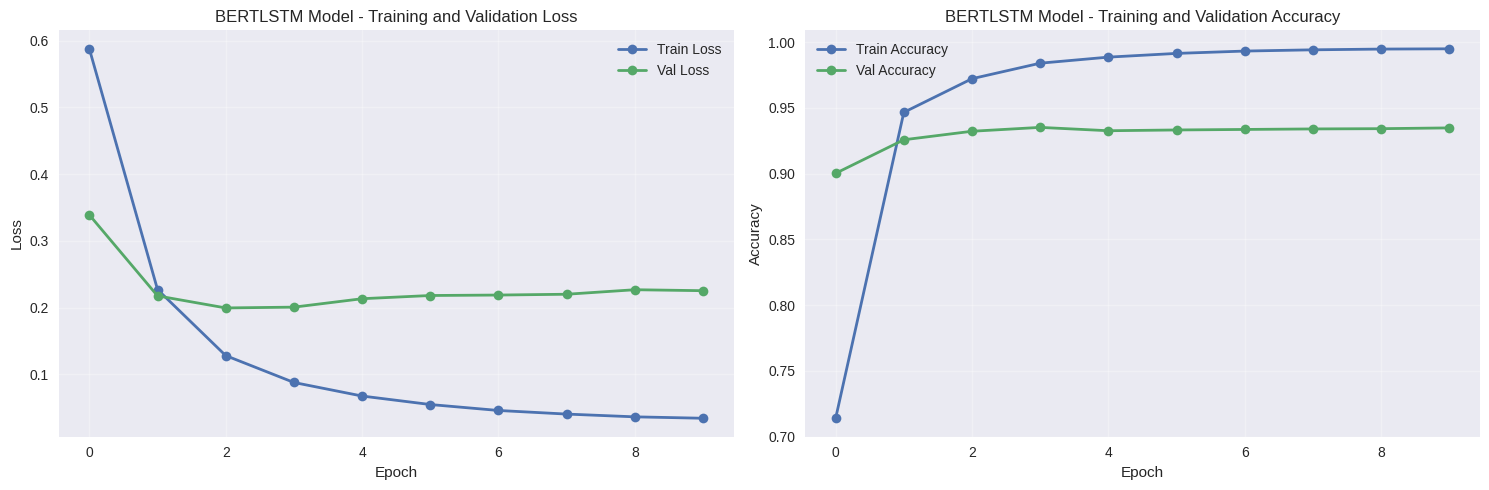

In [33]:
# ========================
# 8. PLOT TRAINING HISTORY
# ========================

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='o', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('BERTLSTM Model - Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', marker='o', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('BERTLSTM Model - Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('BERTLSTM_training_history.png', dpi=300, bbox_inches='tight')
plt.show()


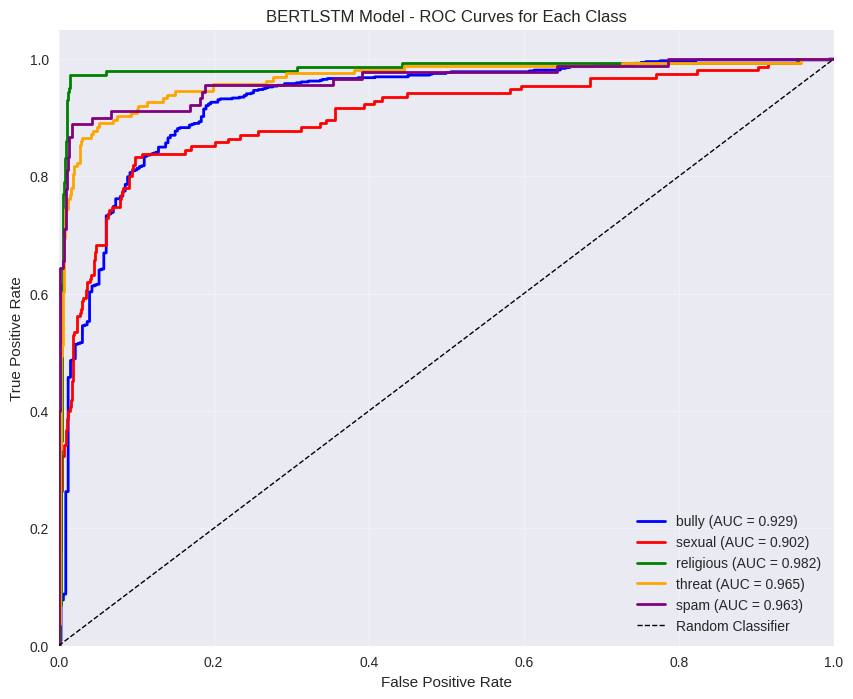

In [34]:
# ========================
# 9. PLOT ROC CURVES
# ========================

# Plot ROC curves for each class
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i, label in enumerate(label_cols):
    try:
        fpr, tpr, _ = roc_curve(test_labels[:, i], test_probs[:, i])
        auc = roc_auc_score(test_labels[:, i], test_probs[:, i])
        plt.plot(fpr, tpr, color=colors[i], linewidth=2,
                label=f'{label} (AUC = {auc:.3f})')
    except ValueError:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BERTLSTM Model - ROC Curves for Each Class')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('BERTLSTM_ROC_curves.png', dpi=300, bbox_inches='tight')
plt.show()


COMPREHENSIVE CONFUSION MATRIX


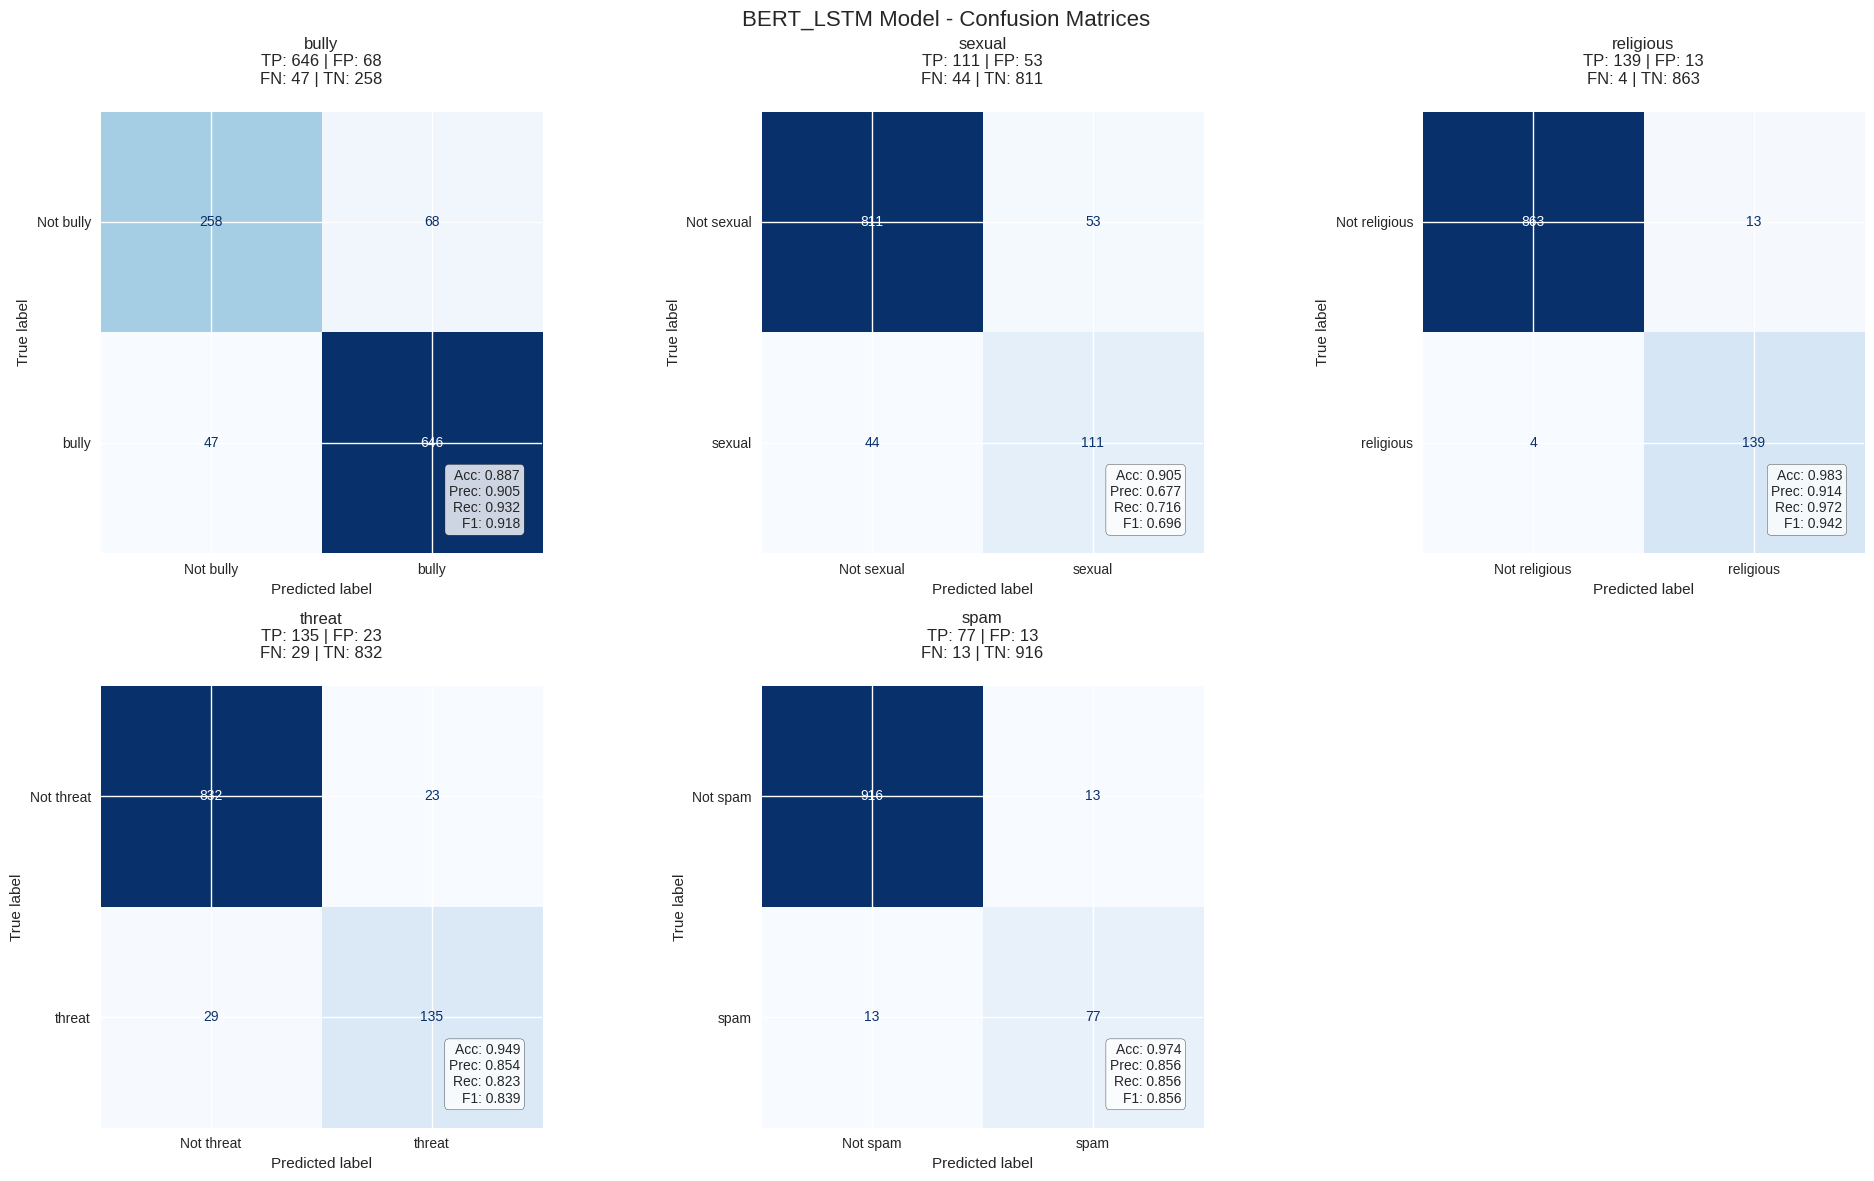

In [35]:
# Add this import at the top
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay


# ========================
# CONFUSION MATRIX SECTION
# ========================

print(f"\n{'='*50}")
print("COMPREHENSIVE CONFUSION MATRIX")
print(f"{'='*50}")

# Create multilabel confusion matrix
mcm = multilabel_confusion_matrix(test_labels, test_preds)

# Plot a single comprehensive figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, (label, cm) in enumerate(zip(label_cols, mcm)):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not '+label, label])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f'{label}\nTP: {cm[1,1]} | FP: {cm[0,1]}\nFN: {cm[1,0]} | TN: {cm[0,0]}',
                     fontsize=12, pad=20)

    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # Add metrics as text
    metrics_text = f'Acc: {accuracy:.3f}\nPrec: {precision:.3f}\nRec: {recall:.3f}\nF1: {f1:.3f}'
    axes[i].text(0.95, 0.05, metrics_text, transform=axes[i].transAxes,
                verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                fontsize=10)

# Hide the last subplot if we have odd number of labels
if len(label_cols) < len(axes):
    for i in range(len(label_cols), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('BERT_LSTM Model - Confusion Matrices', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()



In [36]:
# ========================
# 10. SAMPLE PREDICTIONS
# ========================

def predict_cyberbullying(text, model, tokenizer, device, threshold=0.5):
    """Predict cyberbullying categories for a single text"""
    model.eval()

    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        preds = (probs > threshold).astype(int)

    results = {label: {'prediction': int(pred), 'probability': float(prob)}
               for label, pred, prob in zip(label_cols, preds, probs)}

    return results

# Display 3 sample predictions from test data
print(f"\n{'='*50}")
print("SAMPLE PREDICTIONS FROM TEST DATA - BERTLSTM")
print(f"{'='*50}")

# Get 3 random samples from test set
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), 3, replace=False)

for i, idx in enumerate(sample_indices, 1):
    sample_text = X_test[idx]
    true_labels = y_test[idx]

    print(f"\nSample {i}:")
    print(f"Text: {sample_text}")

    # Get predictions
    predictions = predict_cyberbullying(sample_text, model, tokenizer, device)

    print("Predictions:")
    for label in label_cols:
        pred = predictions[label]['prediction']
        prob = predictions[label]['probability']
        true = int(true_labels[label_cols.index(label)])

        status = "✓" if pred == true else "✗"
        print(f"  {label}: Pred={pred} (prob: {prob:.3f}), True={true}")


SAMPLE PREDICTIONS FROM TEST DATA - BERTLSTM

Sample 1:
Text: চলচ্চিত্র জগতে জাহিদের কি অবদান আরেকজনকে কিভাবে অপমান করে তাকে জুতাপেটা করা দরকার
Predictions:
  bully: Pred=1 (prob: 0.984), True=1
  sexual: Pred=0 (prob: 0.017), True=0
  religious: Pred=0 (prob: 0.012), True=0
  threat: Pred=1 (prob: 0.981), True=1
  spam: Pred=0 (prob: 0.009), True=0

Sample 2:
Text: সবার সাপোর্ট চাই ভাই আইডিটা ফিরিয়ে গেছেএকটু সাপোর্ট কইরা দিয়েন
Predictions:
  bully: Pred=0 (prob: 0.010), True=0
  sexual: Pred=0 (prob: 0.014), True=0
  religious: Pred=0 (prob: 0.011), True=0
  threat: Pred=0 (prob: 0.006), True=0
  spam: Pred=1 (prob: 0.987), True=1

Sample 3:
Text: দুধটা খুইলা একটু ভালো করে করলা একটু মজা লাগবে
Predictions:
  bully: Pred=1 (prob: 0.990), True=1
  sexual: Pred=1 (prob: 0.981), True=1
  religious: Pred=0 (prob: 0.007), True=0
  threat: Pred=0 (prob: 0.013), True=0
  spam: Pred=0 (prob: 0.014), True=0


# ================= END =============================